In [108]:
import os
import logging
import copy
import re
from glob import glob
from pathlib import Path
import numpy as np
from scipy.optimize import curve_fit
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from z2vqe.experiments.tools import clean_array
from z2vqe.experiments.qfim import get_rsat_lcritical

logging.basicConfig(level=logging.INFO)

In [109]:
configs = ['g_m_h', 'g_m_hsp', 'gsp_m_h', 'm_h', 'g_h']
num_fs = np.arange(2, 7)
datadir = Path('/data/iiyama/z2vqe')

## Subspace dimensions

In [110]:
generators = {}
subspaces = {}
hamiltonians = {}
for config in configs:
    generators[config] = {}
    subspaces[config] = {}
    hamiltonians[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'generators-{config}-{num_f}.h5', 'r', libver='latest') as source:
            generators[config][int(num_f)] = source['gen_mats'][()]
            subspaces[config][int(num_f)] = source['subspace'][()]
            hamiltonians[config][int(num_f)] = source['hamiltonian'][()]

In [111]:
subspace_dims = {conf: np.array([subspaces[conf][nf].shape[1] for nf in num_fs]) for conf in configs}
subspace_dims

{'g_m_h': array([  5,  10,  20,  47, 118]),
 'g_m_hsp': array([  8,  16,  36,  84, 224]),
 'gsp_m_h': array([  8,  16,  36,  84, 224]),
 'm_h': array([ 3,  6,  9, 18, 27]),
 'g_h': array([  5,  10,  20,  47, 118])}

In [112]:
# Adjust subspace reduction not due to symmetries
subspace_dims['g_h'][1] -= 1
subspace_dims['g_h'][3] -= 1

In [113]:
{conf: {nf: clean_array(np.trace(gen, axis1=1, axis2=2)) for nf, gen in gens.items()} for conf, gens in generators.items()}

{'g_m_h': {2: array([0., 4., 0.]),
  3: array([0., 4., 0.]),
  4: array([0., 8., 0.]),
  5: array([1.47615253e-12, 1.00000000e+01, 0.00000000e+00]),
  6: array([ 0., 16.,  0.])},
 'g_m_hsp': {2: array([0., 0., 0., 0.]),
  3: array([0., 0., 0., 0.]),
  4: array([0., 0., 0., 0.]),
  5: array([0., 0., 0., 0.]),
  6: array([0., 0., 0., 0.])},
 'gsp_m_h': {2: array([0., 0., 0., 0.]),
  3: array([0., 0., 0., 0.]),
  4: array([0., 0., 0., 0.]),
  5: array([0., 0., 0., 0.]),
  6: array([0., 0., 0., 0.])},
 'm_h': {2: array([0., 0.]),
  3: array([0., 0.]),
  4: array([0., 0.]),
  5: array([0., 0.]),
  6: array([0., 0.])},
 'g_h': {2: array([0., 0.]),
  3: array([0., 0.]),
  4: array([0., 0.]),
  5: array([0., 0.]),
  6: array([0., 0.])}}

INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode


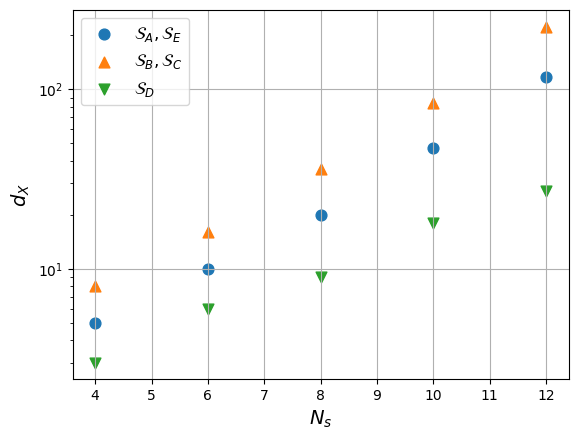

In [114]:
series = [
    ('g_m_h', r'$\mathcal{S}_A, \mathcal{S}_E$', 'o'),
    ('g_m_hsp', r'$\mathcal{S}_B, \mathcal{S}_C$', '^'),
    ('m_h', r'$\mathcal{S}_D$', 'v')
]
for config, symm, marker in series:
    plt.scatter(2 * num_fs, subspace_dims[config], 60., marker=marker, label=symm)

plt.grid()
plt.xlabel('$N_s$', fontsize=14)
plt.ylabel('$d_X$', fontsize=14)
plt.yscale('log')
plt.legend(fontsize=12)
plt.savefig('/home/iiyama/src/z2vqe/plots/symsect_dim.pdf')

## Verifying irreducibility

In [115]:
sbds = {}
reducibles = []

for config in configs:
    sbds[config] = {}
    for inf, num_f in enumerate(num_fs[:-1]):
        with h5py.File(datadir / f'sbd-{config}-{num_f}.h5', 'r', libver='latest') as source:
            tr = source['transform'][()]
            blocks = [source[f'block{i}'][()] for i in range(len(source.keys()) - 1)]
            sbds[config][num_f] = (tr, blocks)
            if len(blocks) > 1:
                reducibles.append((config, num_f))

In [116]:
reducibles

[('g_h', np.int64(3)), ('g_h', np.int64(5))]

## DLA dimensions

In [117]:
dlas = {}

for config in configs:
    dlas[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'dla-{config}-{num_f}.h5', 'r', libver='latest') as source:
            dlas[config][int(num_f)] = source['dla_dim'][()]

In [118]:
dlas

{'g_m_h': {2: np.int64(25),
  3: np.int64(100),
  4: np.int64(400),
  5: np.int64(2209),
  6: np.int64(13924)},
 'g_m_hsp': {2: np.int64(63),
  3: np.int64(255),
  4: np.int64(1296),
  5: np.int64(7056),
  6: np.int64(50176)},
 'gsp_m_h': {2: np.int64(63),
  3: np.int64(255),
  4: np.int64(1296),
  5: np.int64(7056),
  6: np.int64(50176)},
 'm_h': {2: np.int64(3),
  3: np.int64(6),
  4: np.int64(6),
  5: np.int64(9),
  6: np.int64(9)},
 'g_h': {2: np.int64(10),
  3: np.int64(36),
  4: np.int64(190),
  5: np.int64(2208),
  6: np.int64(13924)}}

In [119]:
for config, nf in [('g_m_hsp', 4), ('g_m_hsp', 5), ('g_m_hsp', 6), ('gsp_m_h', 4), ('gsp_m_h', 5), ('gsp_m_h', 6), ('g_h', 4), ('g_h', 6)]:
    print(config, nf)
    print(generators[config][nf].shape[1] ** 2, dlas[config][nf])
    print(clean_array(np.trace(generators[config][nf], axis1=1, axis2=2)))

g_m_hsp 4
1296 1296
[0. 0. 0. 0.]
g_m_hsp 5
7056 7056
[0. 0. 0. 0.]
g_m_hsp 6
50176 50176
[0. 0. 0. 0.]
gsp_m_h 4
1296 1296
[0. 0. 0. 0.]
gsp_m_h 5
7056 7056
[0. 0. 0. 0.]
gsp_m_h 6
50176 50176
[0. 0. 0. 0.]
g_h 4
400 190
[0. 0.]
g_h 6
13924 13924
[0. 0.]


In [120]:
for config, nf in reducibles:
    print(config, nf)
    print(sbds[config][nf][1][1].shape[1] ** 2, dlas[config][nf])
    print(clean_array(np.trace(sbds[config][nf][1][1], axis1=1, axis2=2)))

g_h 3
81 36
[0. 0.]
g_h 5
2116 2208
[0. 0.]


In [121]:
# Correct by hand
dlas['g_m_hsp'][4] -= 1
dlas['g_m_hsp'][5] -= 1
dlas['g_m_hsp'][6] -= 1
dlas['gsp_m_h'][4] -= 1
dlas['gsp_m_h'][5] -= 1
dlas['gsp_m_h'][6] -= 1
dlas['g_h'][4] = 190
for nf in [4, 5, 6]:
    dlas['g_h'][nf] = subspaces['g_h'][nf].shape[1] * (subspaces['g_h'][nf].shape[1] - 1) // 2

In [122]:
dla_dims = {conf: np.array([dlas[conf][nf] for nf in num_fs]) for conf in configs}

INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode


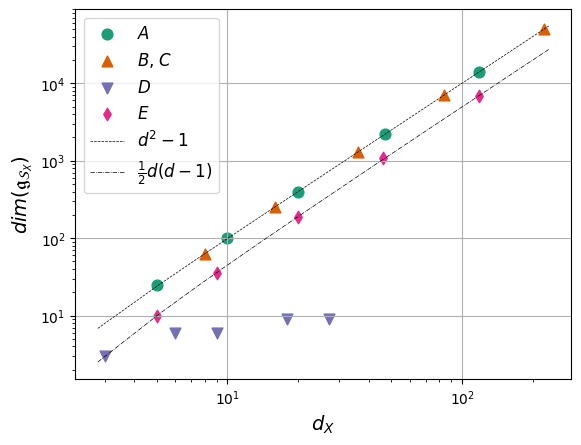

In [123]:
series = [
    ('g_m_h', '$A$', 'o'),
    ('gsp_m_h', '$B$, $C$', '^'),
    ('m_h', '$D$', 'v'),
    ('g_h', '$E$', 'd')
]
colors = mpl.color_sequences['Dark2']

for (config, label, marker), color in zip(series, colors):
    plt.scatter(subspace_dims[config], dla_dims[config], 40. if marker == 'd' else 60., color=color, marker=marker, label=label)
xfine = np.linspace(min(s[0] for s in subspace_dims.values()) - 0.2, max(s[-1] for s in subspace_dims.values()) + 10, 100)
plt.plot(xfine, xfine ** 2 - 1, color='k', linestyle='--', linewidth=0.5, label='$d^2 - 1$')
plt.plot(xfine, xfine * (xfine - 1) / 2, color='k', linestyle='-.', linewidth=0.5, label=r'$\frac{1}{2}d(d-1)$')

plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=12);
plt.xlabel('$d_X$', fontsize=14)
plt.ylabel(r'$dim (\mathfrak{g}_{\mathcal{S}_X})$', fontsize=14)
plt.grid()

plt.savefig('/home/iiyama/src/z2vqe/plots/dim_dla.pdf')

## QFIM saturation

In [124]:
rsats = {}
lcriticals = {}
qfim_ranks = {}
qfim_nls = {}

for config in configs:
    rsats[config] = {}
    lcriticals[config] = {}
    qfim_ranks[config] = {}
    qfim_nls[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'qfim-{config}-{num_f}.h5', 'r', libver='latest') as source:
            ranks = source['ranks'][()]
            num_layers = source['num_layers'][()]
            rsat, lcritical = get_rsat_lcritical(ranks, num_layers)
            rsats[config][int(num_f)] = rsat
            lcriticals[config][int(num_f)] = lcritical
            qfim_ranks[config][int(num_f)] = ranks
            qfim_nls[config][int(num_f)] = num_layers

In [125]:
rsats

{'g_m_h': {2: np.float64(8.0),
  3: np.float64(18.0),
  4: np.float64(38.0),
  5: np.float64(92.0),
  6: np.float64(234.0)},
 'g_m_hsp': {2: np.float64(14.0),
  3: np.float64(30.0),
  4: np.float64(70.0),
  5: np.float64(166.0),
  6: np.float64(446.0)},
 'gsp_m_h': {2: np.float64(14.0),
  3: np.float64(30.0),
  4: np.float64(70.0),
  5: np.float64(166.0),
  6: np.float64(446.0)},
 'm_h': {2: np.float64(2.0),
  3: np.float64(4.0),
  4: np.float64(4.0),
  5: np.float64(6.0),
  6: np.float64(6.0)},
 'g_h': {2: np.float64(4.0),
  3: np.float64(8.0),
  4: np.float64(19.0),
  5: np.float64(45.0),
  6: np.float64(117.0)}}

In [126]:
lcriticals

{'g_m_h': {2: np.int64(4),
  3: np.int64(7),
  4: np.int64(14),
  5: np.int64(32),
  6: np.int64(79)},
 'g_m_hsp': {2: np.int64(5),
  3: np.int64(8),
  4: np.int64(18),
  5: np.int64(42),
  6: np.int64(112)},
 'gsp_m_h': {2: np.int64(5),
  3: np.int64(9),
  4: np.int64(19),
  5: np.int64(43),
  6: np.int64(113)},
 'm_h': {2: np.int64(2),
  3: np.int64(5),
  4: np.int64(4),
  5: np.int64(5),
  6: np.int64(5)},
 'g_h': {2: np.int64(3),
  3: np.int64(5),
  4: np.int64(11),
  5: np.int64(24),
  6: np.int64(61)}}

In [127]:
rsat_nums = {conf: np.array([rsats[conf][nf] for nf in num_fs]) for conf in configs}

<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1068411/3902587505.py:20: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$\overline{R}_{\psi}$', fontsize=14)
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode


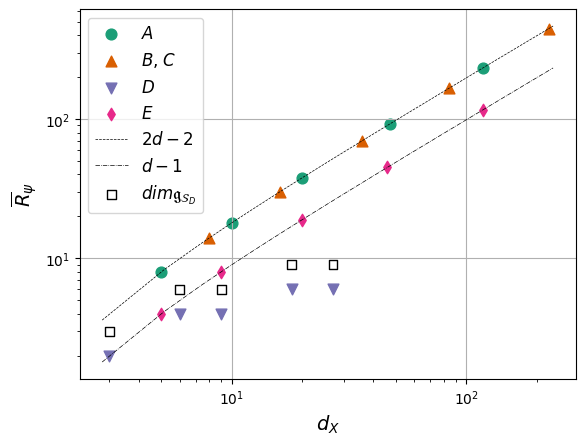

In [128]:
series = [
    ('g_m_h', '$A$', 'o'),
    ('gsp_m_h', '$B$, $C$', '^'),
    ('m_h', '$D$', 'v'),
    ('g_h', '$E$', 'd')
]
colors = mpl.color_sequences['Dark2']

for (config, label, marker), color in zip(series, colors):
    plt.scatter(subspace_dims[config], rsat_nums[config], 40. if marker == 'd' else 60., color=color, marker=marker, label=label)
xfine = np.linspace(min(s[0] for s in subspace_dims.values()) - 0.2, max(s[-1] for s in subspace_dims.values()) + 10, 100)
plt.plot(xfine, xfine * 2 - 2, color='k', linestyle='--', linewidth=0.5, label='$2d - 2$')
plt.plot(xfine, xfine - 1, color='k', linestyle='-.', linewidth=0.5, label='$d - 1$')
plt.scatter(subspace_dims['m_h'], dla_dims['m_h'], 40., color='k', marker='s', facecolor='none', label=r'$dim \mathfrak{g}_{\mathcal{S}_D}$')

plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=12);
plt.xlabel('$d_X$', fontsize=14)
plt.ylabel('$\overline{R}_{\psi}$', fontsize=14)
plt.grid()

plt.savefig('/home/iiyama/src/z2vqe/plots/qfim_rsat.pdf')

### Maximum QFIM rank and loss landscape

In [129]:
nls = {}
qfim_ranks = {}
vqe_losses = {}
vqe_grads = {}
for config in configs:
    nls[config] = {}
    qfim_ranks[config] = {}
    vqe_losses[config] = {}
    vqe_grads[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'vqe-{config}-{num_f}.h5', 'r', libver='latest') as source:
            nls[config][num_f] = source['num_layers'][()]
            qfim_ranks[config][num_f] = source['ranks'][()]
            vqe_losses[config][num_f] = source['losses'][()]
            vqe_grads[config][num_f] = source['gradients'][()]
            print(config, num_f, nls[config][num_f].shape, vqe_grads[config][num_f].shape)

g_m_h 2 (6,) (6, 1024)
g_m_h 3 (6,) (6, 1024)
g_m_h 4 (6,) (6, 1024)
g_m_h 5 (9,) (9, 1024)
g_m_h 6 (13,) (13, 1024)
g_m_hsp 2 (6,) (6, 1024)
g_m_hsp 3 (6,) (6, 1024)
g_m_hsp 4 (6,) (6, 1024)
g_m_hsp 5 (9,) (9, 1024)
g_m_hsp 6 (15,) (15, 1024)
gsp_m_h 2 (6,) (6, 1024)
gsp_m_h 3 (6,) (6, 1024)
gsp_m_h 4 (7,) (7, 1024)
gsp_m_h 5 (9,) (9, 1024)
gsp_m_h 6 (15,) (15, 1024)
m_h 2 (5,) (5, 1024)
m_h 3 (6,) (6, 1024)
m_h 4 (6,) (6, 1024)
m_h 5 (6,) (6, 1024)
m_h 6 (6,) (6, 1024)
g_h 2 (6,) (6, 1024)
g_h 3 (6,) (6, 1024)
g_h 4 (6,) (6, 1024)
g_h 5 (7,) (7, 1024)
g_h 6 (11,) (11, 1024)


INFO:matplotlib.mathtext:Substituting symbol L from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol L from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol L from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol L from STIXNonUnicode


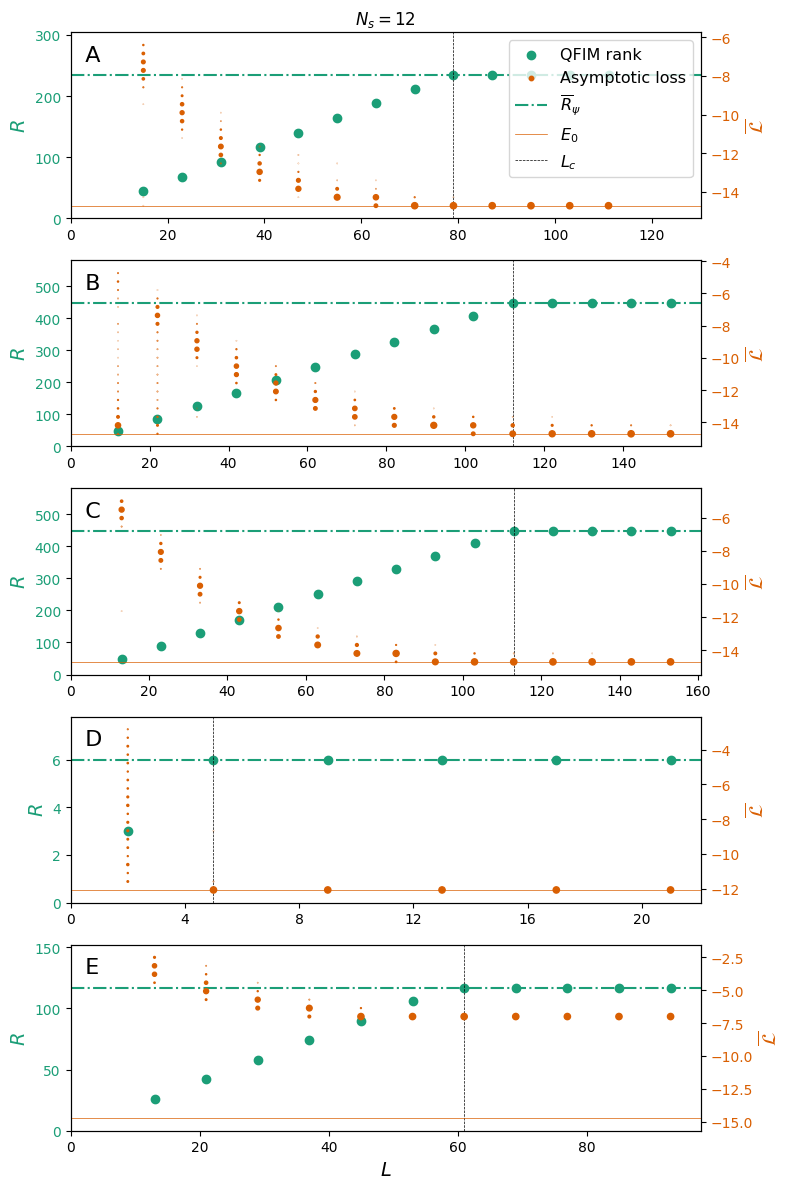

In [130]:
num_f = 6
fig, axs = plt.subplots(5, 1, figsize=(8, 12))
colors = mpl.color_sequences['Dark2']
nbins = 20

for iconfig, (config, cname) in enumerate(zip(configs, ['A', 'B', 'C', 'D', 'E'])):
    exact_e0 = np.linalg.eigvalsh(hamiltonians[config][num_f])[0]
    axl = axs[iconfig]
    axr = axl.twinx()

    hqr = axl.scatter(nls[config][num_f], np.mean(qfim_ranks[config][num_f], axis=1), color=colors[0],
                      marker='o')
    hrpsi = axl.axhline(rsats[config][num_f], color=colors[0], linestyle='-.')
    axl.set_ylabel('$R$', color=colors[0], fontsize=14)
    axl.tick_params(axis='y', labelcolor=colors[0])
    axl.set_ylim(0., np.max(qfim_ranks[config][num_f]) * 1.3)
    hlc = axl.axvline(lcriticals[config][num_f], color='k', linestyle='--', linewidth=0.5, label='$L_c$')

    ymax = np.max(vqe_losses[config][num_f])
    binsize = (ymax - exact_e0) / (nbins - 0.5)
    ymin = exact_e0 - binsize * 0.5
    for nl, data in zip(nls[config][num_f], vqe_losses[config][num_f]):
        hist, edges = np.histogram(data, bins=nbins, range=(ymin, ymax))
        hal = axr.scatter(np.full(nbins, nl), (edges[:-1] + edges[1:]) * 0.5, s=hist * 0.02,
                          color=colors[1])
    he0 = axr.axhline(exact_e0, color=colors[1], linestyle='-', linewidth=0.5, label='$E_0$')
    axr.set_ylabel(r'$\overline{\mathcal{L}}$', color=colors[1], fontsize=14)
    axr.set_ylim(ymin - binsize, ymax + binsize)
    axr.tick_params(axis='y', labelcolor=colors[1])

    axl.text(0, np.max(qfim_ranks[config][num_f]) * 1.1, f'  {cname}', fontsize=16, ha='left')
    axl.set_xlim(0., np.max(nls[config][num_f]) * 1.05)

    if iconfig == 0:
        axr.set_xlim(0., 130.)
        axr.legend(
            [hqr, hal, hrpsi, he0, hlc],
            ['QFIM rank', 'Asymptotic loss', r'$\overline{R}_{\psi}$', '$E_0$', '$L_c$'],
            fontsize=11.5
        )
    if iconfig == 3:
        ticks = np.arange(0, 23, 4)
        axr.set_xticks(ticks, labels=[f'{x}' for x in ticks])

axs[0].set_title('$N_s = 12$')
axs[-1].set_xlabel('$L$', fontsize=14)

fig.tight_layout()
fig.savefig('/home/iiyama/src/z2vqe/plots/rank_loss.pdf')

### Decay rate

In [131]:
vqe_grads[config][num_f].shape

(11, 1024)

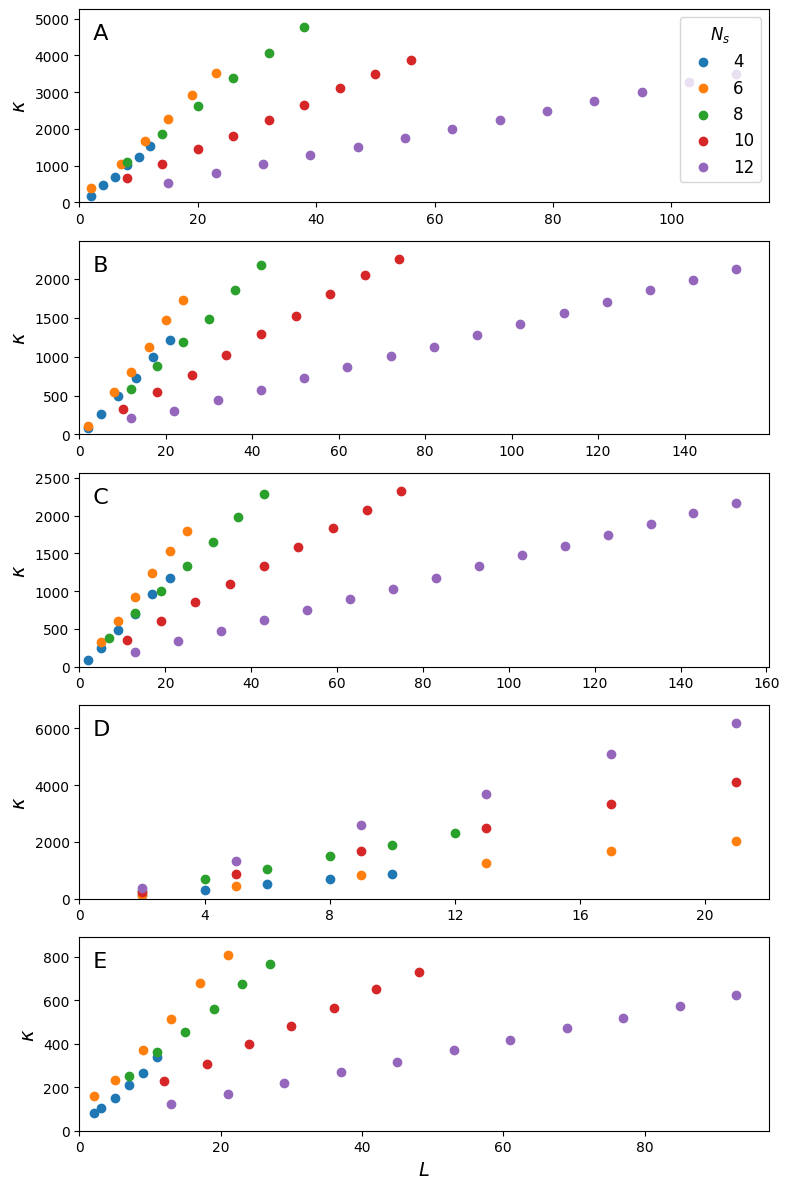

In [132]:
fig, axs = plt.subplots(5, 1, figsize=(8, 12))
for iconfig, (config, cname) in enumerate(zip(configs, ['A', 'B', 'C', 'D', 'E'])):
    ax = axs[iconfig]
    mean_ends = []
    for num_f in num_fs:
        x = nls[config][num_f]
        y = np.mean(vqe_grads[config][num_f], axis=1)
        ax.scatter(x, y, label=f'{2 * num_f}')
        mean_ends.append(y[-1])

    ax.text(0, np.max(mean_ends) * 0.93, f'  {cname}', fontsize=16, ha='left')
    ax.set_xlim(0., np.max(nls[config][6]) * 1.05)
    ax.set_ylim(0., np.max(mean_ends) * 1.1)
    ax.set_ylabel(r'$\kappa$', fontsize=14)

    if iconfig == 0:
        ax.legend(title='$N_s$', fontsize=12, title_fontsize=12)
    if iconfig == 3:
        ticks = np.arange(0, 23, 4)
        ax.set_xticks(ticks, labels=[f'{x}' for x in ticks])

axs[-1].set_xlabel('$L$', fontsize=14)
fig.tight_layout()
fig.savefig('/home/iiyama/src/z2vqe/plots/decay_rate.pdf')